# Notebook 03 — Real-Data Evaluation on S&P 500

**Kernel:** deep hedging environment (Python 3.11+, torch)

**Prerequisites:** 
- `01_gad_calibration.ipynb` — data in `data/sp500_prices/` and `data/gad_params_fix.json`
- `02_gad_training.ipynb` — models in `results/real_data/`

Steps:
1. Build real test windows from S&P 500 constituent prices
2. Load trained networks
3. Compute hedging errors and entropic risk for all methods
4. Primary results table
5. Sector breakdown
6. Realised-volatility quintile breakdown
7. Data-efficiency: entropic risk vs. training sample size N
8. BS delta analytical baseline

In [14]:
import sys
import json
import time
from functools import partial
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

PROJECT_ROOT = Path(".").resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR    = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results" / "real_data"

def _auto_device() -> torch.device:
    if torch.cuda.is_available():           return torch.device("cuda")
    if torch.backends.mps.is_available():   return torch.device("mps")
    return torch.device("cpu")

DEVICE = _auto_device()
print(f"Device: {DEVICE}")

Device: mps


In [15]:
from src.gad_simulator import GADParams, GADSimulator
from src.hedging.hedge_network import HedgeNet
from src.hedging.loss import EntropicOCELoss
from src.hedging.gad_adv_trainer import (
    gad_budget_attack,
    train_adv_gad,
    compute_errors,
    calibrate_bn_stats,
)
from src.hedging.theoretical import bs_delta
from src.real_data.sp500_loader import build_test_windows, compute_entropic_risk

## 1. Load GAD Params & Build Real Test Windows

In [16]:
with open(DATA_DIR / "gad_params_fix.json") as f:
    p_dict = json.load(f)

N_STEPS  = 30
T        = 30 / 252
S0       = 10.0
K        = 10.0

# Evaluation lambda matches He et al. (1.3, not training lambda 13).
LAMB     = 1.3

# Annualised log-return vol: σ = (a0 + a1*S0) / S0  (dimensionless).
# Do NOT use a0 + a1*S0 directly — that has price units, not vol%.
SIGMA_EFF = (p_dict["a0"] + p_dict["a1"] * S0) / S0

loss_fn = EntropicOCELoss(K=K, sigma=SIGMA_EFF, T=T, lamb=LAMB, X_max=True, x_max_val=-1.0)
print(f"σ_eff = {SIGMA_EFF:.2%}  (annualised log-return vol)")
print(f"Evaluation λ = {LAMB}")

σ_eff = 13.58%  (annualised log-return vol)
Evaluation λ = 1.3


In [17]:
print("Building real test windows …")
t0 = time.perf_counter()
S_real, ticker_labels = build_test_windows(
    DATA_DIR / "sp500_prices",
    T=N_STEPS,
    S0_norm=S0,
)
print(f"  Real windows: {S_real.shape}  ({time.perf_counter()-t0:.1f}s)")
print(f"  Unique tickers in test set: {len(set(ticker_labels))}")

Building real test windows …
  Real windows: torch.Size([461513, 31])  (3.3s)
  Unique tickers in test set: 498


## 2. Load Trained Networks

In [18]:
def load_net(name: str) -> HedgeNet:
    net = HedgeNet(N=N_STEPS, width=20)
    net.load_state_dict(torch.load(RESULTS_DIR / f"{name}_net.pt", map_location="cpu", weights_only=True))
    return net

net_clean = load_net("clean")
net_adv   = load_net("adv")
net_bs    = load_net("bs_deep")
print("Loaded: clean, adv, bs_deep")

Loaded: clean, adv, bs_deep


## 2b. Test-Time BatchNorm Adaptation

The networks were trained on GAD paths with σ≈10% (SPY calibration). Real test stocks
span σ≈5%–60%, so `log(S_t)` inputs can be 10–40 σ outside the training BN statistics,
producing extreme hedge ratios on high-vol stocks (the -184/-723 results seen without this step).

**Fix:** reset all BN running statistics, then recompute them from the real test paths
(network weights unchanged). This is standard test-time domain adaptation.

In [19]:
print("Calibrating BN statistics to real test distribution …")
t0 = time.perf_counter()

# calibrate_bn_stats resets all BN running_mean/running_var, then runs
# the full test set through the network in train() mode to accumulate
# fresh statistics. Weights are frozen (no gradients computed).
net_clean = calibrate_bn_stats(net_clean, S_real, DEVICE)
net_adv   = calibrate_bn_stats(net_adv,   S_real, DEVICE)
net_bs    = calibrate_bn_stats(net_bs,    S_real, DEVICE)

print(f"Done in {time.perf_counter()-t0:.1f}s")
print("BN statistics now reflect real S&P 500 price distribution.")

Calibrating BN statistics to real test distribution …
Done in 8.0s
BN statistics now reflect real S&P 500 price distribution.


## 3. Compute Hedging Errors on Real Paths

In [20]:
print("Computing hedging errors …")
errors_clean = compute_errors(net_clean, S_real, K, DEVICE)
errors_adv   = compute_errors(net_adv,   S_real, K, DEVICE)
errors_bs_nn = compute_errors(net_bs,    S_real, K, DEVICE)
print(f"  {len(errors_clean):,} paths evaluated")

Computing hedging errors …
  461,513 paths evaluated


In [21]:
# ── Black-Scholes delta analytical baseline ──────────────────────────────────
@torch.no_grad()
def bs_delta_errors(S: torch.Tensor, K: float, sigma: float, T: float) -> torch.Tensor:
    """Compute hedging errors for the BS delta hedge."""
    N   = S.shape[1] - 1
    dt  = T / N
    PnL = torch.zeros(S.shape[0])
    for t in range(N):
        tau = (N - t) * dt
        delta_t = bs_delta(S[:, t], tau, K, sigma)
        PnL += delta_t * (S[:, t + 1] - S[:, t])
    C_T = torch.clamp(S[:, -1] - K, min=0.0)
    return C_T - PnL

errors_bs_delta = bs_delta_errors(S_real, K, SIGMA_EFF, T)
print(f"BS delta errors computed. Shape: {errors_bs_delta.shape}")

BS delta errors computed. Shape: torch.Size([461513])


## 4. Primary Results Table

In [22]:
methods = {
    "BS Delta (analytical)": errors_bs_delta,
    "BS Deep Hedger":         errors_bs_nn,
    "Clean (GAD)": errors_clean,
    "Adversarial (GAD)": errors_adv,
}

print("\n" + "─" * 52)
print(f"  {'Method':<28s}  {'Entropic Risk':>13s}")
print("─" * 52)
for name, errs in methods.items():
    rho = compute_entropic_risk(errs, lamb=LAMB)
    print(f"  {name:<28s}  {rho:>13.5f}")
print("─" * 52)
print("  (λ = 1.0, real S&P 500 rolling windows 2020–2023)")


────────────────────────────────────────────────────
  Method                        Entropic Risk
────────────────────────────────────────────────────
  BS Delta (analytical)               0.41374
  BS Deep Hedger                      0.42855
  Clean (GAD)                         0.42150
  Adversarial (GAD)                   0.35874
────────────────────────────────────────────────────
  (λ = 1.0, real S&P 500 rolling windows 2020–2023)


## 6. Realised-Volatility Quintile Breakdown

In [23]:
# Realised vol per 30-day window = std of daily log-returns
log_returns = torch.log(S_real[:, 1:] / S_real[:, :-1])   # (M, N)
rv_per_path = log_returns.std(dim=1) * np.sqrt(252)        # annualised

quintile_labels = pd.qcut(rv_per_path.numpy(), q=5, labels=["Q1 (low)", "Q2", "Q3", "Q4", "Q5 (high)"])

rv_results = defaultdict(dict)
for q in quintile_labels.categories:
    mask = torch.tensor(quintile_labels == q)
    for name, errs in methods.items():
        rv_results[str(q)][name] = compute_entropic_risk(errs[mask], lamb=LAMB)

rv_df = pd.DataFrame(rv_results).T
rv_df.index.name = "Vol quintile"
rv_df.round(4)

,BS Delta (analytical),BS Deep Hedger,Clean (GAD),Adversarial (GAD)
Vol quintile,,,,
Q1 (low),0.2354,0.2628,0.2622,0.2649
Q2,0.3192,0.3305,0.3280,0.3033
Q3,0.3934,0.3950,0.3899,0.3405
Q4,0.4888,0.4920,0.4823,0.3980
Q5 (high),0.7166,0.7504,0.7241,0.5103


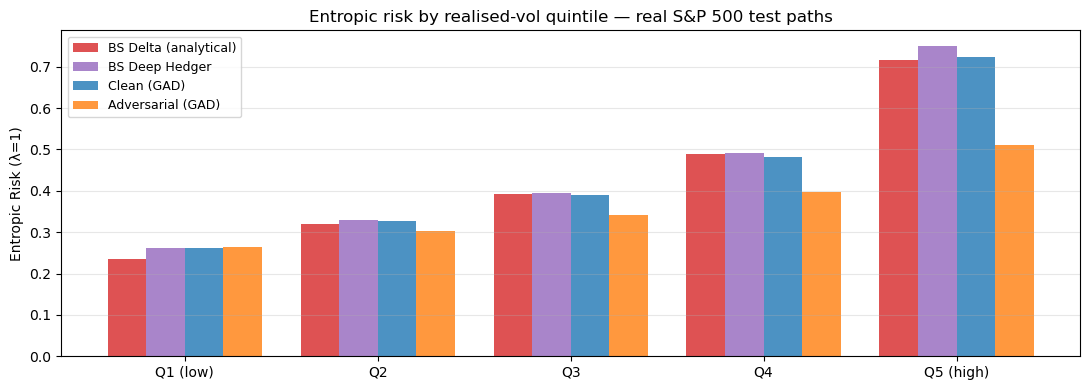

In [24]:
w      = 0.2   # bar width (4 methods × 0.2 = 0.8 per quintile group)
colors = ['C3', 'C4', 'C0', 'C1']  # BS-delta, BS-deep, Clean, Adversarial

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(rv_df))

for i, (col, color) in enumerate(zip(rv_df.columns, colors)):
    ax.bar(x + i * w, rv_df[col].values, width=w, label=col, color=color, alpha=0.8)

ax.set_xticks(x + 1.5 * w)
ax.set_xticklabels(rv_df.index, fontsize=10)
ax.set_ylabel("Entropic Risk (λ=1)")
ax.set_title("Entropic risk by realised-vol quintile — real S&P 500 test paths")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "vol_quintile_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Data Efficiency: Entropic Risk vs. Training Sample Size N

In [25]:
N_SIZES  = [5_000, 10_000, 20_000, 50_000, 100_000]
N_SEEDS  = 3
LAMB     = 1.3  # evaluation lambda (He et al.)

with open(RESULTS_DIR / "best_hps.json") as f:
    best_hps = json.load(f)
best_alpha = best_hps["alpha_bal"]
best_delta = best_hps["delta"]

train_loss_fn = EntropicOCELoss(K=K, sigma=SIGMA_EFF, T=T, lamb=13.0,
                                X_max=True, x_max_val=-1.0)

params_full = GADParams(b0=0., b1=0., a0=p_dict["a0"], a1=p_dict["a1"],
                        gamma=p_dict.get("gamma", 1.0),
                        S0=S0, T=T, N=N_STEPS, M=100_000)
S_tr_full = GADSimulator(params_full).simulate(seed=19).to(DEVICE)

de_results = {"clean": {}, "adv": {}}

adv_atk = partial(gad_budget_attack, loss_fn=train_loss_fn, delta=best_delta, iters=5)

for N in N_SIZES:
    risks_clean = []
    risks_adv   = []
    n_seeds_run = min(N_SEEDS, 100_000 // N)

    for s in range(n_seeds_run):
        S_sub = S_tr_full[s * N : (s + 1) * N]
        p0_init_val = float(train_loss_fn.bs_price(torch.tensor(S0)).item())

        # Clean — calibrate BN to test distribution before evaluating
        nc, _, _ = train_adv_gad(
            S_sub, attack_fn=None, loss_fn=train_loss_fn,
            n_clean=700, n_adv=0, batch_size=min(10_000, N),
            lr=5e-3, alpha_bal=1.0, p0_init=p0_init_val, device=DEVICE,
            desc=f"DE-clean N={N} s{s}",
        )
        nc = calibrate_bn_stats(nc, S_real, DEVICE)
        errs = compute_errors(nc, S_real, K, DEVICE)
        risks_clean.append(compute_entropic_risk(errs, lamb=LAMB))

        # Adversarial — calibrate BN to test distribution before evaluating
        na, _, _ = train_adv_gad(
            S_sub, attack_fn=adv_atk, loss_fn=train_loss_fn,
            n_clean=300, n_adv=400, batch_size=min(10_000, N),
            lr=5e-3, alpha_bal=best_alpha, p0_init=p0_init_val, device=DEVICE,
            desc=f"DE-adv N={N} s{s}",
        )
        na = calibrate_bn_stats(na, S_real, DEVICE)
        errs = compute_errors(na, S_real, K, DEVICE)
        risks_adv.append(compute_entropic_risk(errs, lamb=LAMB))

    de_results["clean"][N] = risks_clean
    de_results["adv"][N]   = risks_adv
    print(f"N={N:6d}  clean={np.mean(risks_clean):.4f}  adv={np.mean(risks_adv):.4f}  (seeds={n_seeds_run})")

torch.save(de_results, RESULTS_DIR / "data_efficiency_results.pt")

DE-clean N=5000 s0:   0%|          | 0/700 [00:00<?]  lc=0.0000  la=0.0000  p0=0.1868

KeyboardInterrupt: 

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

for method, color, label in [("clean", "steelblue", "Clean"), ("adv", "seagreen", "Adversarial")]:
    means = [np.mean(de_results[method][N]) for N in N_SIZES]
    mins_ = [np.min(de_results[method][N])  for N in N_SIZES]
    maxs_ = [np.max(de_results[method][N])  for N in N_SIZES]
    ax.plot(N_SIZES, means, marker="o", linewidth=2, color=color, label=label)
    ax.fill_between(N_SIZES, mins_, maxs_, alpha=0.2, color=color)

ax.set_xscale("log")
ax.set_xlabel("Training sample size N", fontsize=12)
ax.set_ylabel("Entropic risk on real S&P 500 paths", fontsize=12)
ax.set_title("Data efficiency — entropic risk vs. N\n(Shaded: min–max range across seeds)", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle="--")
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
plt.tight_layout()
plt.savefig(RESULTS_DIR / "data_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Final Summary

In [ ]:
print("\n" + "═" * 60)
print("  PRIMARY RESULTS — Real S&P 500 Test Set (2020–2023)")
print("═" * 60)
print(f"  Test paths: {S_real.shape[0]:,}  (rolling 30-day windows)")
print(f"  Unique tickers: {len(set(ticker_labels))}")
print(f"  λ = {LAMB}  (entropic risk-aversion parameter)")
print("─" * 60)
for name, errs in methods.items():
    rho = compute_entropic_risk(errs, lamb=LAMB)
    print(f"  {name:<28s}  ρ = {rho:+.5f}")
print("═" * 60)
print("  (Lower ρ is better. Adversarial < Clean indicates robustness gain.)")